# Name: Bennie Kibet
# Project : Syria Tel analysis

## Business Understanding
## Overview:

Syriatel telecommunications company operating in Kenya offers a variety of plans to their customers, ranging from international plans, voicemail plans,etc. The company has experienced growth but has a challenge in retaining customers, as they opt out of their services (churn). Acquiring new customers is typically more expensive than retaining existing ones, so reducing churn is a high-priority business goal.

## Problem Statement:
To determine whether we can predict which customers are likely to leave soon, so the company can intervene early.

## Key Business Questions

* Are there patterns in customer behavior that signal churn?
* Which customers are most at risk of leaving soon?
* What factors (e.g., pricing, service usage, complaints) drive churn?

## Metrics:

From a business perspective:

* Reduction in churn rate
* Increase in retained customers
* ROI of retention campaigns

From a model perspective:

* Accuracy - To know how well our model is performing
* Recall (very important) - Catch as many churners as possible
* Precision - Avoid wasting resources on customers who won’t churn
* AUC-ROC - Overall model performance


## Objectives
1. Reduce customer churn
2. Increase customer lifetime value 
3. Improve retention strategies


# Data Understanding

In [1]:
# Importing the relevant libraries
import numpy as np
import math 
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier 
from sklearn.metrics import roc_auc_score, ConfusionMatrixDisplay, classification_report, accuracy_score, confusion_matrix, roc_curve
from sklearn.preprocessing import OneHotEncoder, MinMaxScaler
from imblearn.over_sampling import SMOTE
from sklearn import tree
%matplotlib inline

In [2]:
# Loading the dataset
data = pd.read_csv("Data\Syria_tel.csv")
data.head()

<>:2: SyntaxWarning: invalid escape sequence '\S'
<>:2: SyntaxWarning: invalid escape sequence '\S'
C:\Users\benbe\AppData\Local\Temp\ipykernel_26288\2405028064.py:2: SyntaxWarning: invalid escape sequence '\S'
  data = pd.read_csv("Data\Syria_tel.csv")


,state,account length,area code,phone number,international plan,voice mail plan,number vmail messages,total day minutes,total day calls,total day charge,...,total eve calls,total eve charge,total night minutes,total night calls,total night charge,total intl minutes,total intl calls,total intl charge,customer service calls,churn
0,KS,128,415,382-4657,no,yes,25,265.1,110,45.07,...,99,16.78,244.7,91,11.01,10.0,3,2.70,1,False
1,OH,107,415,371-7191,no,yes,26,161.6,123,27.47,...,103,16.62,254.4,103,11.45,13.7,3,3.70,1,False
2,NJ,137,415,358-1921,no,no,0,243.4,114,41.38,...,110,10.30,162.6,104,7.32,12.2,5,3.29,0,False
3,OH,84,408,375-9999,yes,no,0,299.4,71,50.90,...,88,5.26,196.9,89,8.86,6.6,7,1.78,2,False
4,OK,75,415,330-6626,yes,no,0,166.7,113,28.34,...,122,12.61,186.9,121,8.41,10.1,3,2.73,3,False


In [3]:
data.describe()

,account length,area code,number vmail messages,total day minutes,total day calls,total day charge,total eve minutes,total eve calls,total eve charge,total night minutes,total night calls,total night charge,total intl minutes,total intl calls,total intl charge,customer service calls
count,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000
mean,101.064806,437.182418,8.099010,179.775098,100.435644,30.562307,200.980348,100.114311,17.083540,200.872037,100.107711,9.039325,10.237294,4.479448,2.764581,1.562856
std,39.822106,42.371290,13.688365,54.467389,20.069084,9.259435,50.713844,19.922625,4.310668,50.573847,19.568609,2.275873,2.791840,2.461214,0.753773,1.315491
min,1.000000,408.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,23.200000,33.000000,1.040000,0.000000,0.000000,0.000000,0.000000
25%,74.000000,408.000000,0.000000,143.700000,87.000000,24.430000,166.600000,87.000000,14.160000,167.000000,87.000000,7.520000,8.500000,3.000000,2.300000,1.000000
50%,101.000000,415.000000,0.000000,179.400000,101.000000,30.500000,201.400000,100.000000,17.120000,201.200000,100.000000,9.050000,10.300000,4.000000,2.780000,1.000000
75%,127.000000,510.000000,20.000000,216.400000,114.000000,36.790000,235.300000,114.000000,20.000000,235.300000,113.000000,10.590000,12.100000,6.000000,3.270000,2.000000
max,243.000000,510.000000,51.000000,350.800000,165.000000,59.640000,363.700000,170.000000,30.910000,395.000000,175.000000,17.770000,20.000000,20.000000,5.400000,9.000000


In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3333 entries, 0 to 3332
Data columns (total 21 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   state                   3333 non-null   object 
 1   account length          3333 non-null   int64  
 2   area code               3333 non-null   int64  
 3   phone number            3333 non-null   object 
 4   international plan      3333 non-null   object 
 5   voice mail plan         3333 non-null   object 
 6   number vmail messages   3333 non-null   int64  
 7   total day minutes       3333 non-null   float64
 8   total day calls         3333 non-null   int64  
 9   total day charge        3333 non-null   float64
 10  total eve minutes       3333 non-null   float64
 11  total eve calls         3333 non-null   int64  
 12  total eve charge        3333 non-null   float64
 13  total night minutes     3333 non-null   float64
 14  total night calls       3333 non-null   

### Summary of the data

The data set has 21 columns of data(features) and 3333 data entries.

1.  state - The state the customer comes from
2.   account length - The account number of the customer
3.   area code - The assigned code by the state indicating area zones
4.   phone number - Unique identifier of customer
5.   international plan - Shows whether customer has subscribed for the international plan
6.   voice mail plan - Shows whether customer has subscribed for the voice mail plan
7.   number vmail messages - The number of voice mail messages received by a cutomer   
8.   total day minutes - The duration of time spent by customer on calls during the day
9.   total day calls - The number of calls made by cutomer during the day  
10.  total day charge - The charges for making a call during the day
11.  total eve minutes - The duration of time spent by customer on calls during the evening
12.  total eve calls - The number of calls made by cutomer during the evening  
13.  total eve charge - The charges for making a call during the evening
14.  total night minutes - The duration of time spent by customer on calls during the night
15.  total night calls - The number of calls made by cutomer during the night 
16.  total night charge - The charges for making a call during the night
17.  total intl minutes - The duration of time spent by customer on international calls
18.  total intl calls - The number of international calls made by cutomers  
19.  total intl charge - The charges for making an international call
20.  customer service calls - Calls received by the customer care 
21.  churn - Likelyhood of a customer stopping to use the service  

## EDA

In [5]:
# To convert the missing values in the data into nan type
data.replace('-', np.nan, inplace=True)

In [6]:
# Checking for null values in the data
data.isna().sum()

state                     0
account length            0
area code                 0
phone number              0
international plan        0
voice mail plan           0
number vmail messages     0
total day minutes         0
total day calls           0
total day charge          0
total eve minutes         0
total eve calls           0
total eve charge          0
total night minutes       0
total night calls         0
total night charge        0
total intl minutes        0
total intl calls          0
total intl charge         0
customer service calls    0
churn                     0
dtype: int64

In [7]:
# Checking for duplicates in the data
data.duplicated().sum()

0

In [8]:
data["churn"].value_counts()

churn
False    2850
True      483
Name: count, dtype: int64

In [9]:
data["total eve minutes"].value_counts()

total eve minutes
169.9    9
167.2    7
180.5    7
201.0    7
161.7    7
        ..
75.3     1
293.9    1
232.8    1
173.2    1
265.9    1
Name: count, Length: 1611, dtype: int64

In [10]:
data['total eve charge'].value_counts()

total eve charge
14.25    11
16.12    11
15.90    10
17.09     9
18.62     9
         ..
7.85      1
8.63      1
26.54     1
6.74      1
22.60     1
Name: count, Length: 1440, dtype: int64

In [11]:
data['total day charge'].value_counts()

total day charge
26.18    8
27.12    8
29.67    8
31.18    7
29.82    7
        ..
13.36    1
34.15    1
43.23    1
41.99    1
30.74    1
Name: count, Length: 1667, dtype: int64

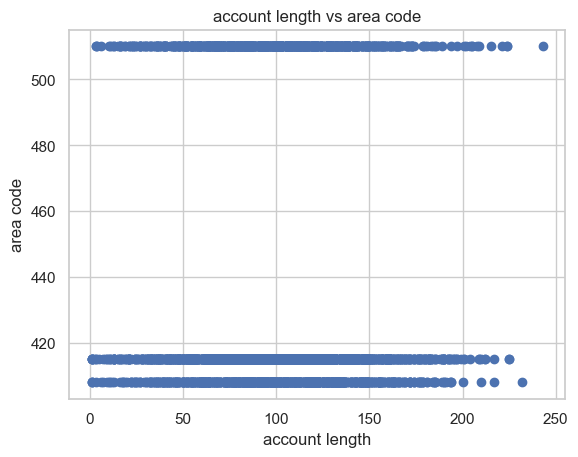

In [51]:
fig, ax = plt.subplots()
ax.scatter(data['account length'], data['area code'])
plt.title('account length vs area code')
ax.set_ylabel("area code")
ax.set_xlabel("account length")
plt.show()

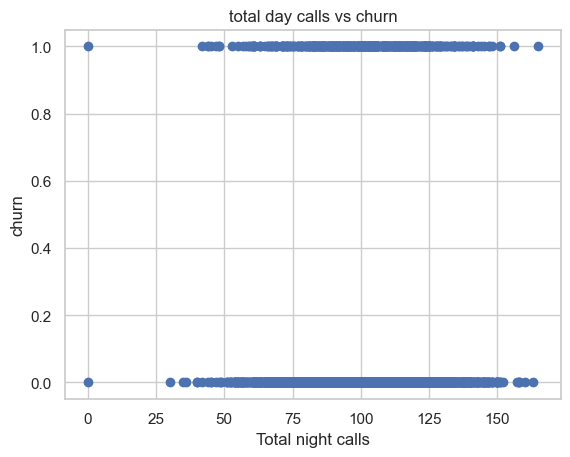

In [52]:
fig, ax = plt.subplots()
ax.scatter(data['total day calls'], data['churn'])
plt.title('total day calls vs churn')
ax.set_ylabel("churn")
ax.set_xlabel("Total night calls")
plt.show()

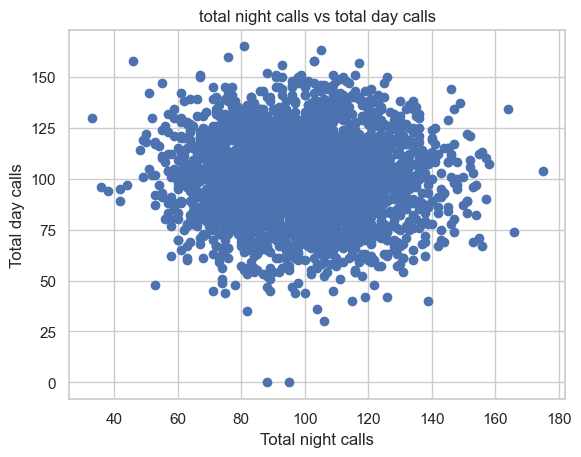

In [49]:
fig, ax = plt.subplots()
ax.scatter(data['total night calls'], data['total day calls'])
plt.title('total night calls vs total day calls')
ax.set_ylabel("Total day calls")
ax.set_xlabel("Total night calls")
plt.show()

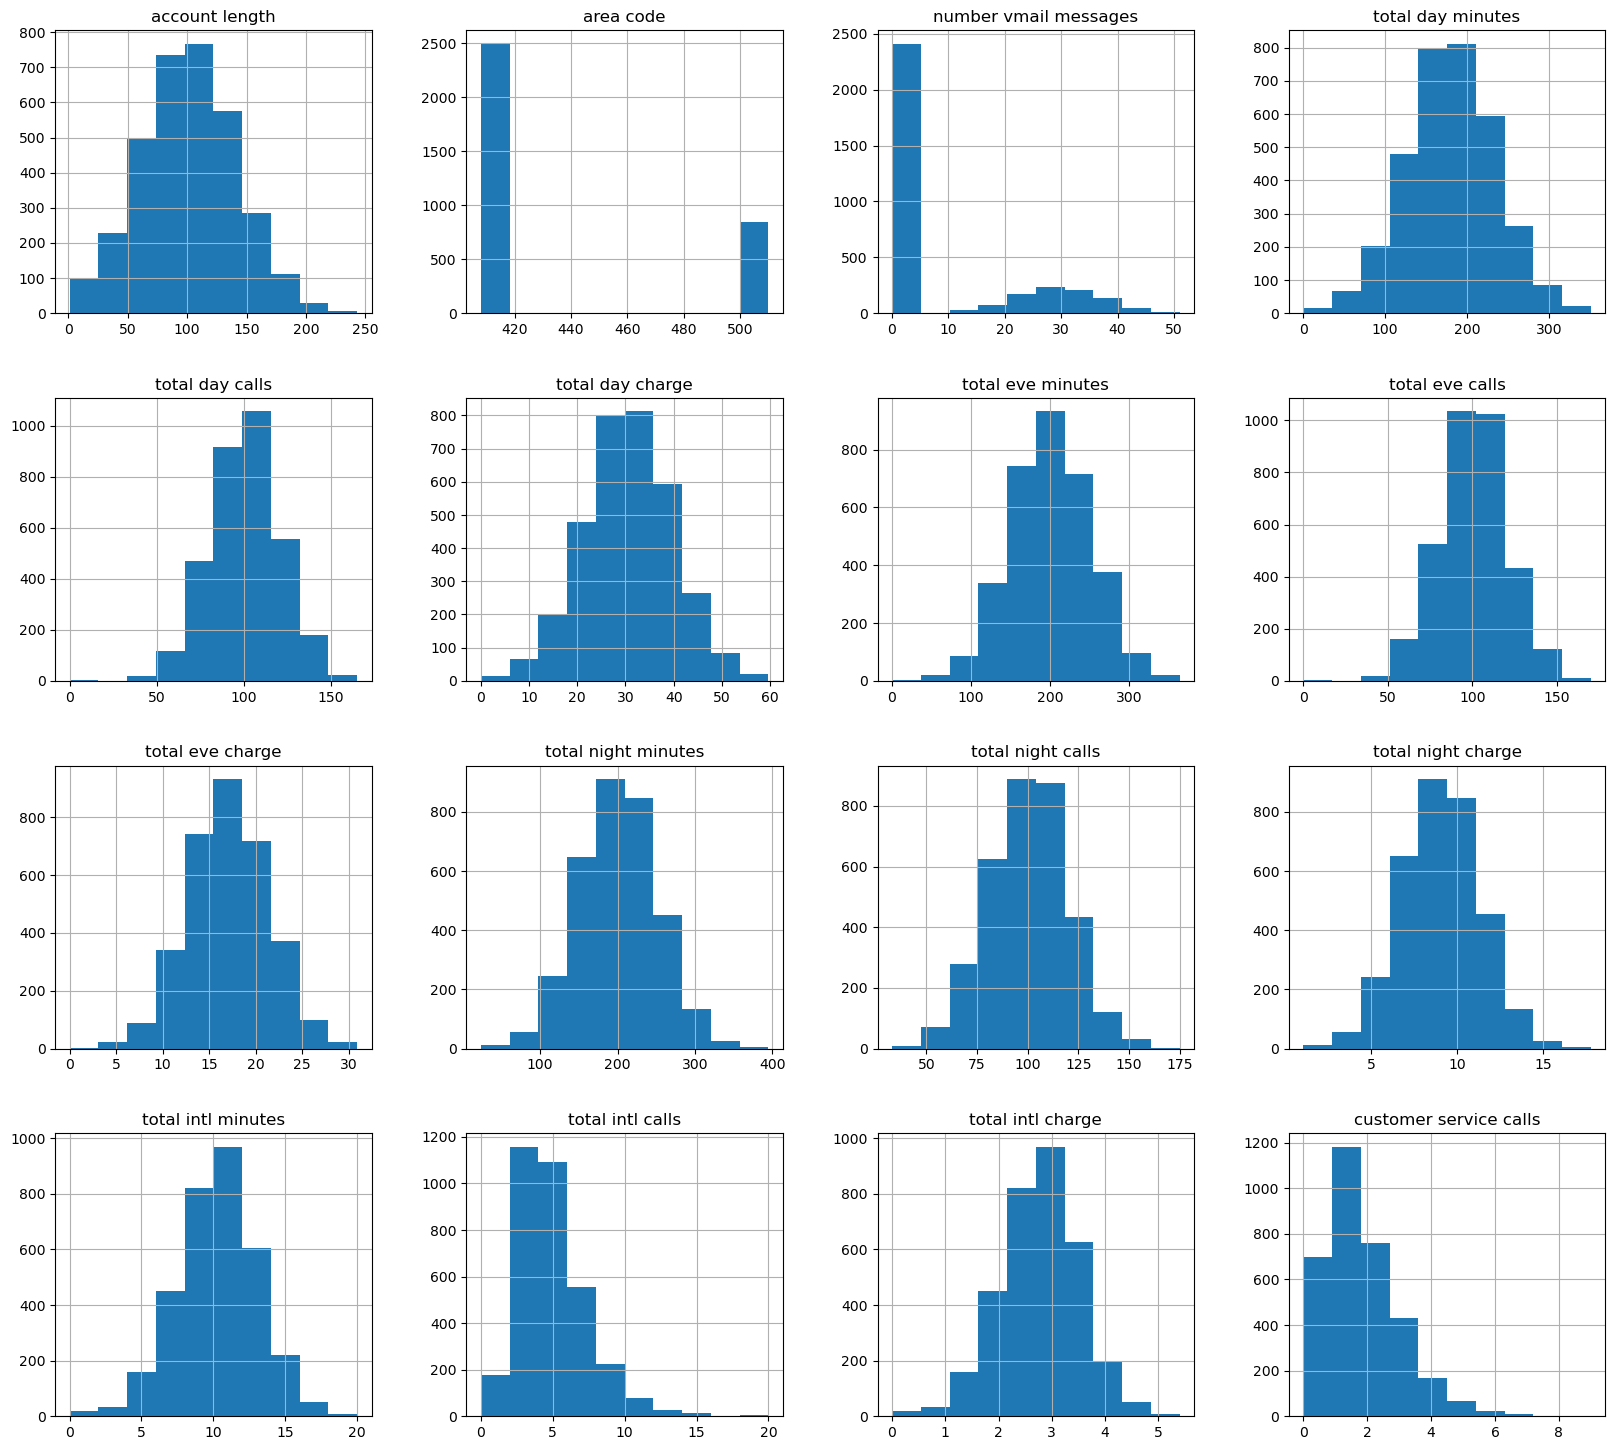

In [15]:
data.hist(figsize = (20,18));

### Discussion
* The distributions show that most usage-related variables (e.g., total day/evening/night minutes and charges) are approximately bell-shaped, suggesting stable and consistent customer behavior across time periods. The close alignment between minutes and corresponding charges indicates strong linear relationships, which is useful for models like Logistic Regression.

* Variables such as number of voicemail messages and customer service calls are highly right-skewed, with many customers having low values and a few having very high counts. This suggests that extreme behaviors (e.g., frequent complaints) may be strong indicators of churn.

* The area code feature appears categorical with limited variation, implying it may have low predictive power unless combined with other regional insights. Similarly, account length is fairly normally distributed, indicating customers are spread across different tenure levels without strong imbalance.

* Call counts (day/evening/night) are moderately normally distributed, reflecting consistent calling patterns, while international calls and minutes are skewed toward lower values, indicating fewer users engage heavily in international usage.

* Overall, the dataset appears well-structured with mostly clean distributions, but skewed variables and potential outliers (especially in service calls and voicemail usage) should be carefully handled, as they could carry strong signals for identifying churn behavior.


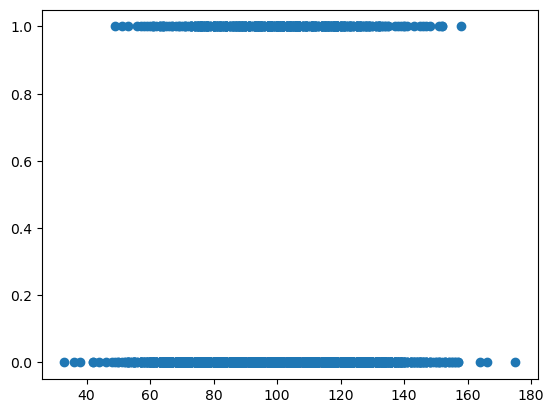

In [16]:
fig, ax = plt.subplots()
ax.scatter(data['total night calls'], data['churn'])

In [17]:
data['phone number'].value_counts()

phone number
382-4657    1
348-7071    1
389-6082    1
415-3689    1
379-2503    1
           ..
352-1127    1
368-1288    1
403-5279    1
397-9333    1
400-4344    1
Name: count, Length: 3333, dtype: int64

In [18]:
data["state"].value_counts()

state
WV    106
MN     84
NY     83
AL     80
WI     78
OH     78
OR     78
WY     77
VA     77
CT     74
MI     73
ID     73
VT     73
TX     72
UT     72
IN     71
MD     70
KS     70
NC     68
NJ     68
MT     68
CO     66
NV     66
WA     66
RI     65
MA     65
MS     65
AZ     64
FL     63
MO     63
NM     62
ME     62
ND     62
NE     61
OK     61
DE     61
SC     60
SD     60
KY     59
IL     58
NH     56
AR     55
GA     54
DC     54
HI     53
TN     53
AK     52
LA     51
PA     45
IA     44
CA     34
Name: count, dtype: int64

In [19]:
data.drop(columns=['phone number', 'state'], inplace=True)
data.columns

Index(['account length', 'area code', 'international plan', 'voice mail plan',
       'number vmail messages', 'total day minutes', 'total day calls',
       'total day charge', 'total eve minutes', 'total eve calls',
       'total eve charge', 'total night minutes', 'total night calls',
       'total night charge', 'total intl minutes', 'total intl calls',
       'total intl charge', 'customer service calls', 'churn'],
      dtype='object')

## Data Preparation

In [20]:
# Splitting the columns based on variable types
categorical_columns = []
numerical_columns = []
for i in data.columns:
    if data[i].dtype == 'O':
        categorical_columns.append(i)
    else:
        numerical_columns.append(i)
        
print(f"Categorical columns:",  categorical_columns) 
print(f"Numerical columns:",  numerical_columns)

Categorical columns: ['international plan', 'voice mail plan']
Numerical columns: ['account length', 'area code', 'number vmail messages', 'total day minutes', 'total day calls', 'total day charge', 'total eve minutes', 'total eve calls', 'total eve charge', 'total night minutes', 'total night calls', 'total night charge', 'total intl minutes', 'total intl calls', 'total intl charge', 'customer service calls', 'churn']


In [21]:
data['international plan'].value_counts()

international plan
no     3010
yes     323
Name: count, dtype: int64

In [22]:
data['voice mail plan'].value_counts()

voice mail plan
no     2411
yes     922
Name: count, dtype: int64

In [23]:
data['account length'].value_counts()

account length
105    43
87     42
101    40
93     40
90     39
       ..
243     1
200     1
232     1
5       1
221     1
Name: count, Length: 212, dtype: int64

In [24]:
# Converting the categorical data to numerical data
encoder = OneHotEncoder(sparse_output=False)

one_hot_encoded = encoder.fit_transform(data[categorical_columns])

one_hot_df = pd.DataFrame(one_hot_encoded, columns=encoder.get_feature_names_out(categorical_columns))

df_encoded = pd.concat([data, one_hot_df], axis=1)

df_encoded = df_encoded.drop(categorical_columns, axis=1)
print(f"Encoded data : \n{df_encoded}")

Encoded data : 
      account length  area code  number vmail messages  total day minutes  \
0                128        415                     25              265.1   
1                107        415                     26              161.6   
2                137        415                      0              243.4   
3                 84        408                      0              299.4   
4                 75        415                      0              166.7   
...              ...        ...                    ...                ...   
3328             192        415                     36              156.2   
3329              68        415                      0              231.1   
3330              28        510                      0              180.8   
3331             184        510                      0              213.8   
3332              74        415                     25              234.4   

      total day calls  total day charge  total eve minutes 

In [25]:
df_encoded.head()

,account length,area code,number vmail messages,total day minutes,total day calls,total day charge,total eve minutes,total eve calls,total eve charge,total night minutes,...,total night charge,total intl minutes,total intl calls,total intl charge,customer service calls,churn,international plan_no,international plan_yes,voice mail plan_no,voice mail plan_yes
0,128,415,25,265.1,110,45.07,197.4,99,16.78,244.7,...,11.01,10.0,3,2.70,1,False,1.0,0.0,0.0,1.0
1,107,415,26,161.6,123,27.47,195.5,103,16.62,254.4,...,11.45,13.7,3,3.70,1,False,1.0,0.0,0.0,1.0
2,137,415,0,243.4,114,41.38,121.2,110,10.30,162.6,...,7.32,12.2,5,3.29,0,False,1.0,0.0,1.0,0.0
3,84,408,0,299.4,71,50.90,61.9,88,5.26,196.9,...,8.86,6.6,7,1.78,2,False,0.0,1.0,1.0,0.0
4,75,415,0,166.7,113,28.34,148.3,122,12.61,186.9,...,8.41,10.1,3,2.73,3,False,0.0,1.0,1.0,0.0


## Checking for Outliers

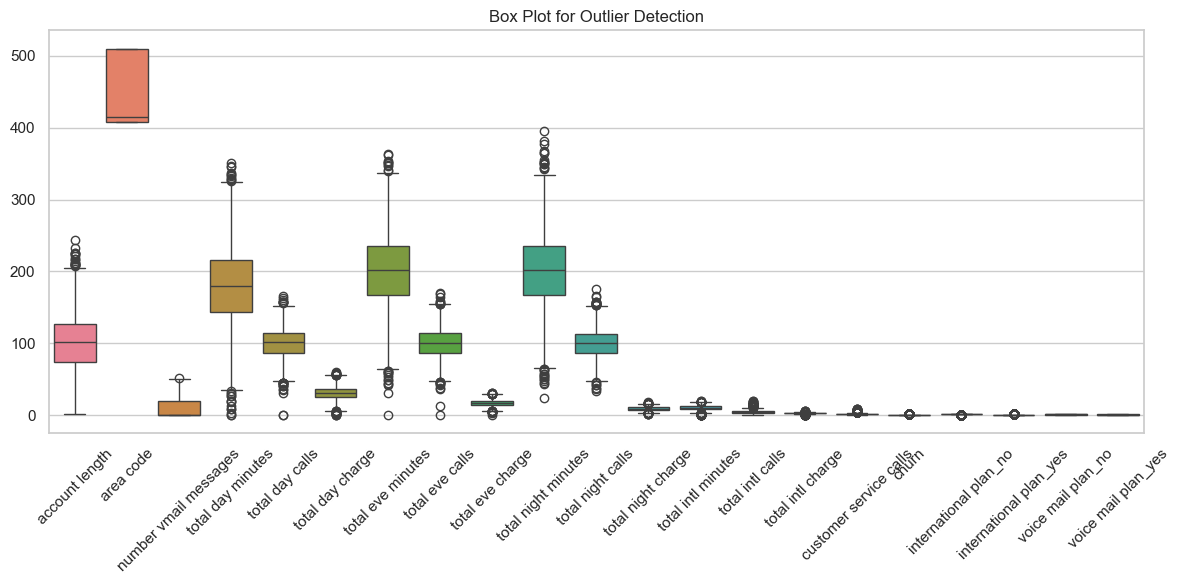

In [26]:
# Set style for better visuals
sns.set(style="whitegrid")

# Plot boxplots for all numeric columns
plt.figure(figsize=(12, 6))
sns.boxplot(data=df_encoded)

# Rotate x-axis labels for readability
plt.xticks(rotation=45)

plt.title("Box Plot for Outlier Detection")
plt.tight_layout()
plt.show()

### Discusion

* The box plot shows that several continuous variables, especially total day, evening, and night minutes and charges, contain noticeable outliers, indicating some customers have unusually high usage.
* The box plot for total evening minutes has a higher average compared to the other minutes indicating more calls occur at night that other times(day, evening) which may be due to the lower night charges average compared to other times(day, evening)
* Customer service calls and number of voicemail messages also exhibit outliers, suggesting a subset of customers with extreme behavior.
* Features like area code and binary plan indicators show little variation and minimal outlier presence.
* The presence of outliers suggests the need for robust modeling or potential treatment (e.g., capping or transformation).
* Overall, variability is highest in usage-related features, which may strongly influence churn predictions.

## Bivariate Analysis

In this section, we will perform bivariate analysis to examine the relationship between the target variable - churn and the other numeric and continuous features in the data. We will use scatter plots to show the direction, strength, and shape of the relationship between two numeric variables. This will help us understand how one variable affects or is affected by another variable and identify any patterns or trends that may exist.

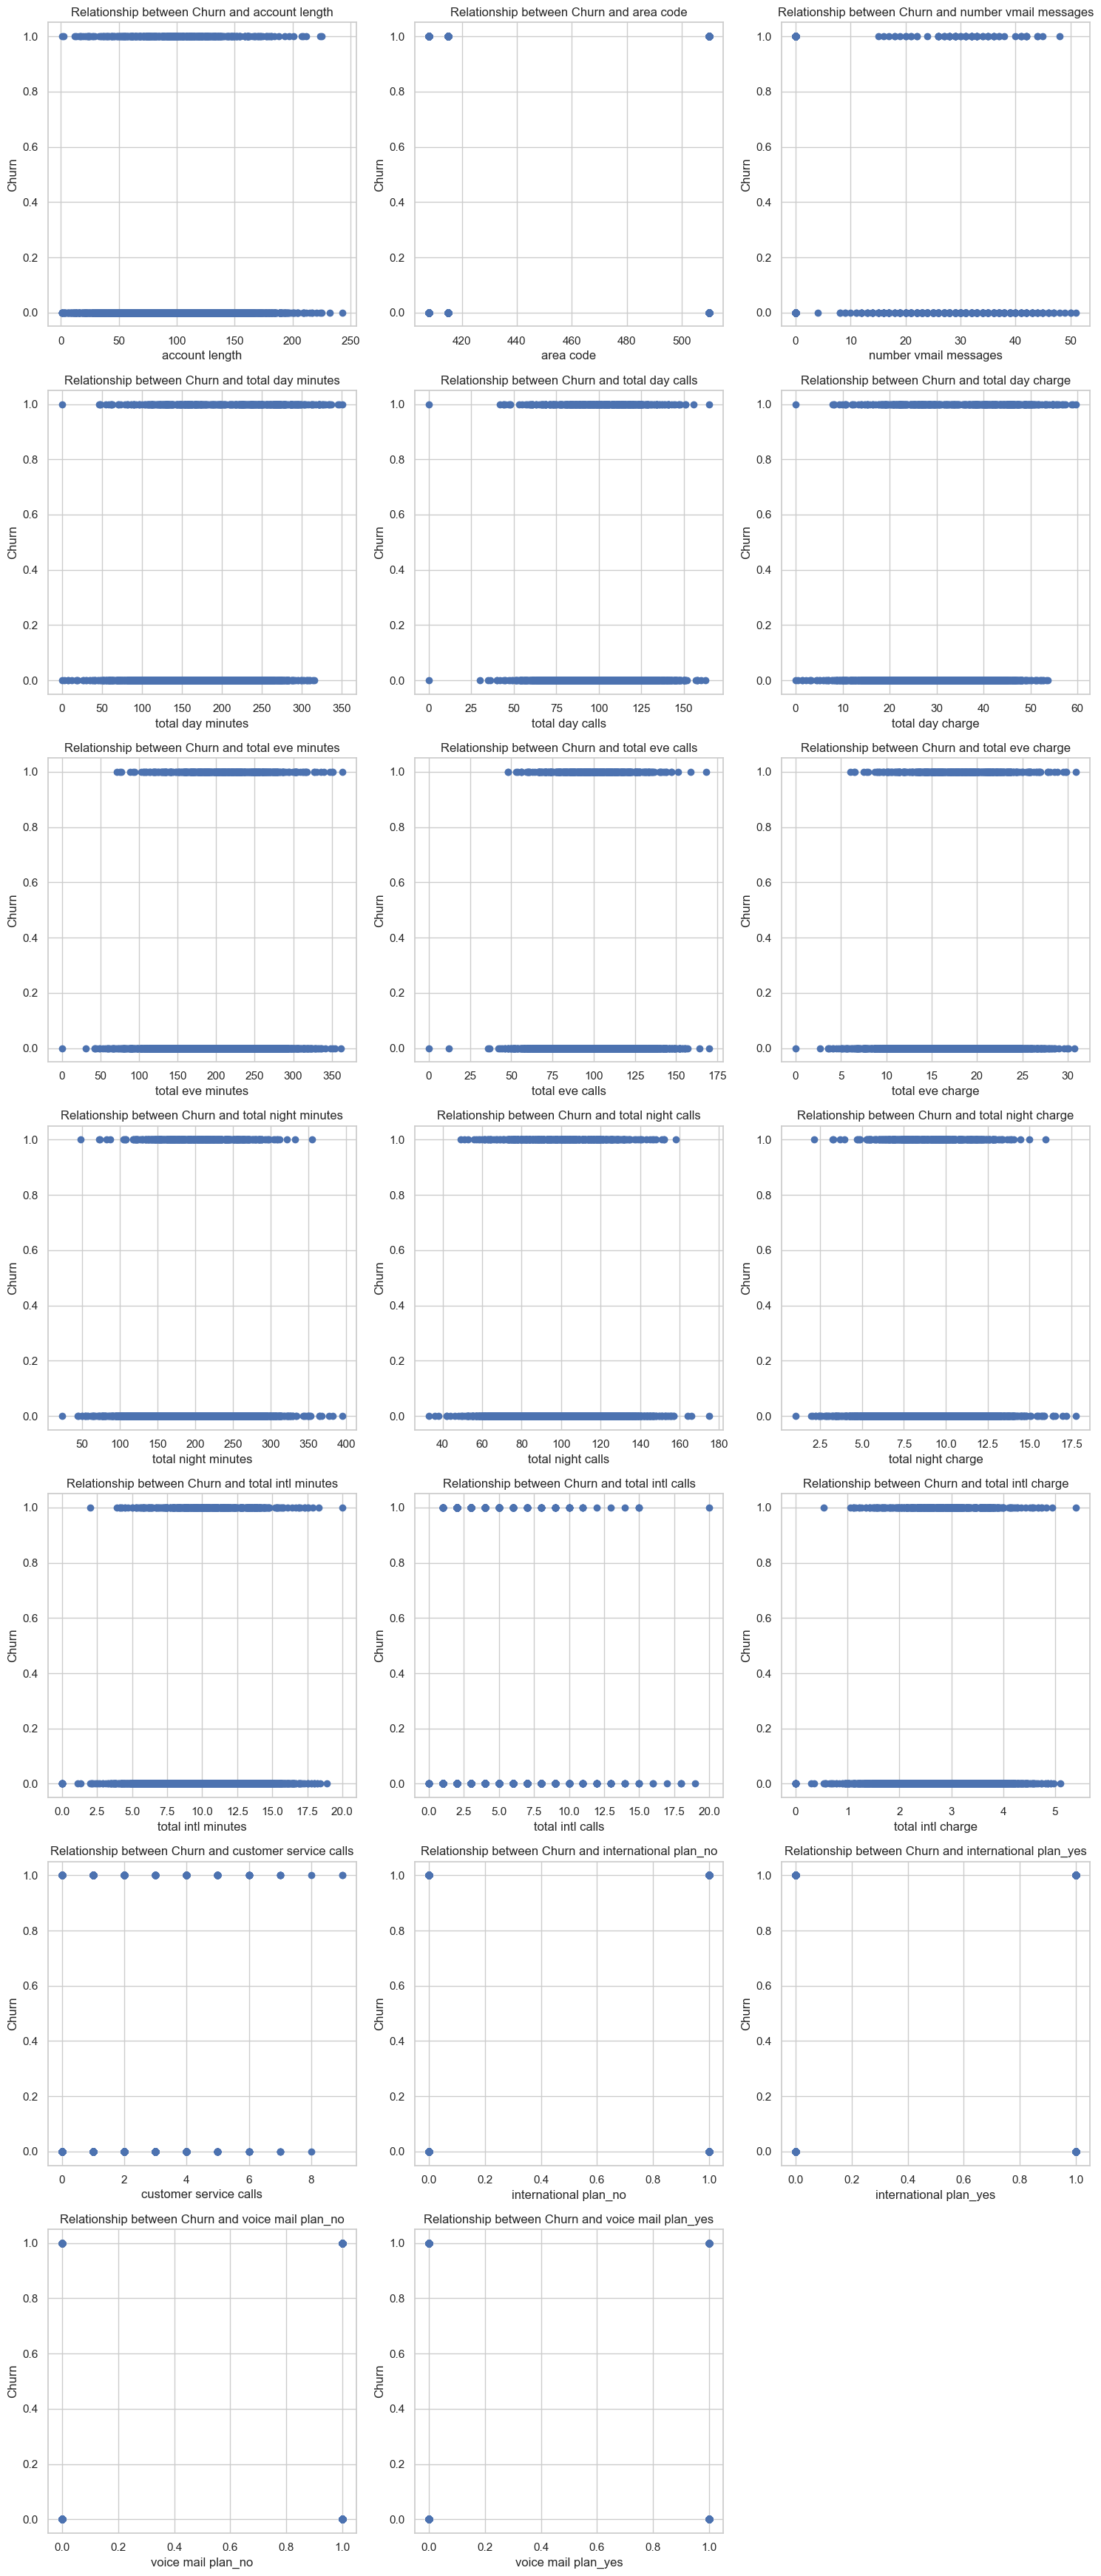

In [27]:
# Examine the relationships between 'churn' and several independent variables through scatter plots
variables = df_encoded.drop('churn', axis=1)
num_rows = math.ceil(len(variables.columns) / 3)  # Calculate the number of rows for the subplots

# Set up a grid of subplots for visualizing relationships
fig, axes = plt.subplots(num_rows, 3, figsize=(15, num_rows * 5))
axes = axes.flatten()  # prevents indexing issues

# Plot scatter plots to explore how each independent variable affects 'price'
for i, var in enumerate(variables.columns):
    row = i // 3  # Compute the row index
    col = i % 3   # Compute the column index
    axes[i].scatter(df_encoded[var], df_encoded['churn'])
    axes[i].set_xlabel(var)  # X-axis label
    axes[i].set_ylabel('Churn')  # Y-axis label
    axes[i].set_title(f'Relationship between Churn and {var}')  # Plot title

# Hide unused subplots
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)
    
# Adjust layout to avoid overlap of subplots
plt.tight_layout()
plt.show()

### Discussion

* Customer churn does not depend on a single factor; most variables show significant overlap between churners and non-churners, indicating the need for a combined model approach.
* The strongest signal comes from customer service calls, where higher call frequency is clearly associated with churn.
* Customers with international plans and those with higher usage (especially day minutes/charges) also show a higher tendency to churn.
* Features like area code and account length appear to have little predictive value.
* Overall, churn is mainly driven by customer dissatisfaction and cost-related factors, which the model can leverage for targeted retention strategies.

## Multivariate Analysis

In this section, we will perform multivariate analysis to examine the relationship between the target variable - churn and multiple features in the data. We will use heatmap to visualize the correlation matrix of the features and see how they are related to each other and to the price.

A heatmap can show us the strength and direction of the correlation between two variables using different colors and shades. This will help us identify the most important features for the prediction and avoid multicollinearity problems.

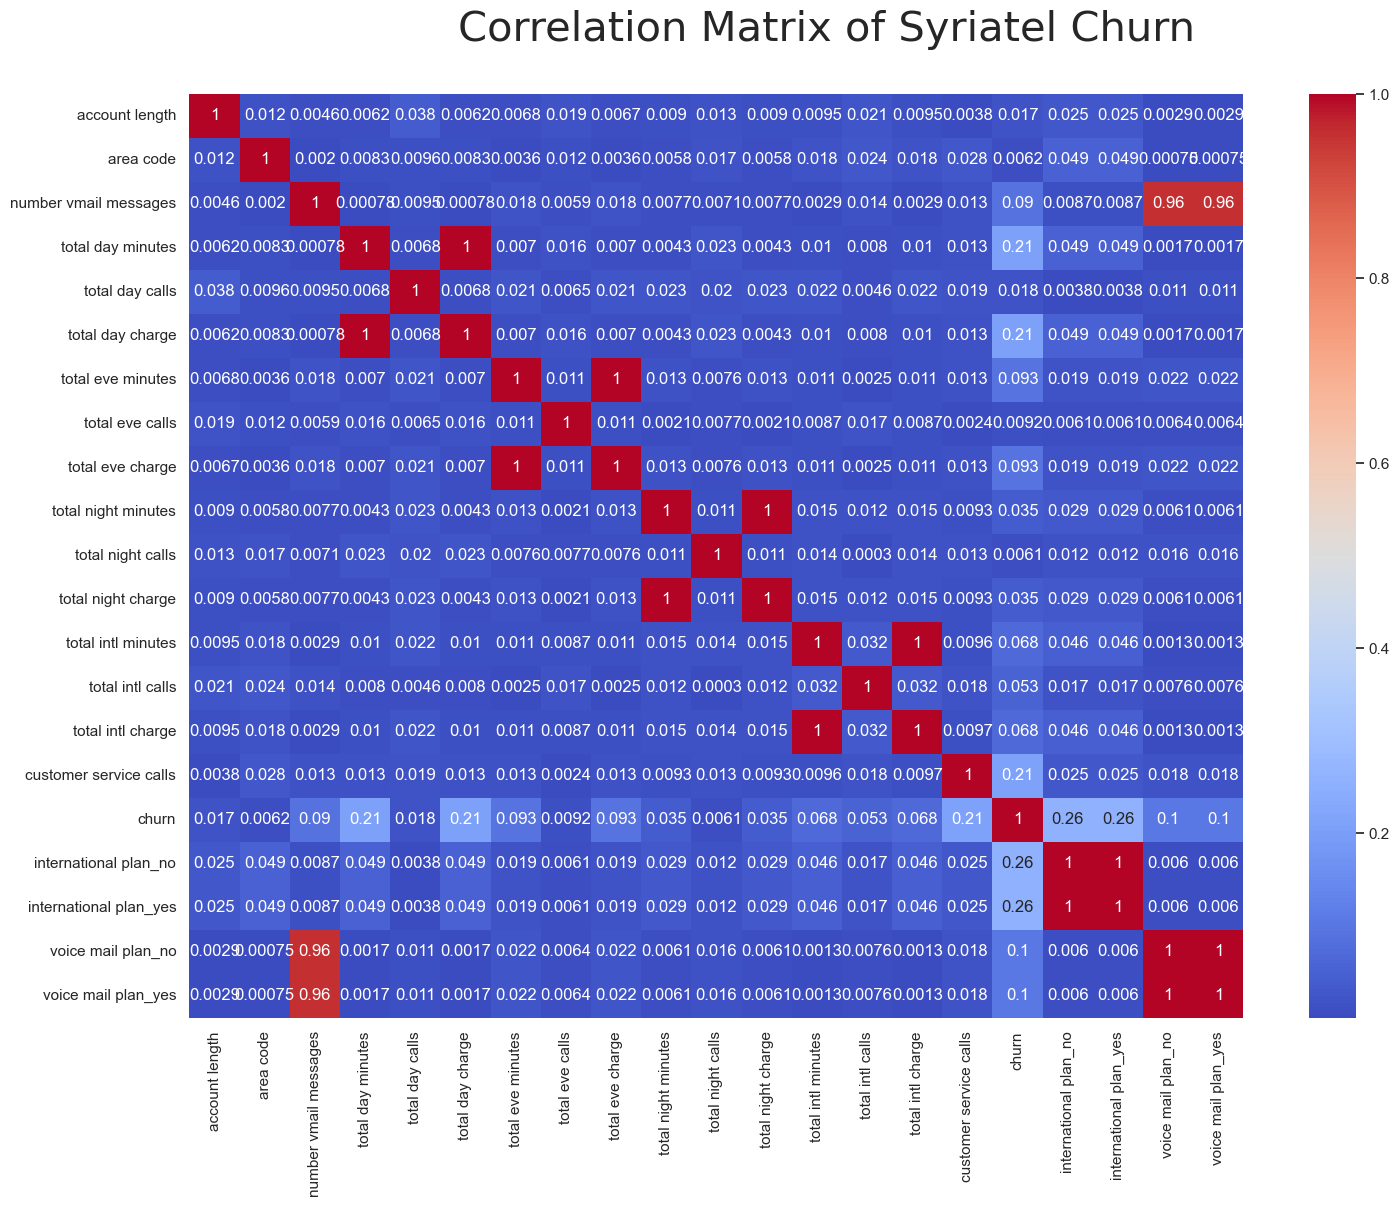

In [54]:
# plot heatmap to show the relationship between various variables
corr = df_encoded.corr().abs()
fig, ax=plt.subplots(figsize=(17,12))
fig.suptitle('Correlation Matrix of Syriatel Churn', fontsize=30, y=.95, fontname='DejaVu Sans')
heatmap = sns.heatmap(corr, cmap='coolwarm', annot=True)
heatmap;

### Discusion

* The correlation matrix shows strong multicollinearity between usage variables and their corresponding charges (e.g., total minutes and total charges are almost perfectly correlated), indicating redundancy.
* Most features have weak correlation with churn, suggesting no single variable strongly predicts customer loss.
* The most notable relationships with churn are customer service calls, international plan, and total day minutes and day charges, though correlations are still moderate.
* Binary features like international plan and voicemail plan are highly correlated within themselves due to encoding.
* Overall, the model will need to rely on combined feature effects rather than individual predictors for accurate churn prediction.


# Modeling

In [29]:
# Identifying the target and features of the model
y = df_encoded['churn']
X = df_encoded.drop(columns='churn', axis=1)

# Train-test splitting the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=15)

In [30]:
# Scaling the data
scaler = MinMaxScaler()

# fitting and transforming the train data
X_train_s = scaler.fit_transform(X_train)

# transforming the test data
X_test_s = scaler.transform(X_test)

In [31]:
# Correcting for class imbalance
smote = SMOTE()
#SMOTE only to the training data
X_train_smote, y_train_smote = smote.fit_resample(X_train_s, y_train)

## Baseline model: Logistic Regression

In [32]:
# defining the model
logreg = LogisticRegression(solver='liblinear')

# fitting the train data
logreg.fit(X_train_smote, y_train_smote)

LogisticRegression(solver='liblinear')

In [33]:
# predicting on unseen data
y_pred = logreg.predict(X_test_s)
print(accuracy_score(y_test, y_pred))
print("\n")
print(classification_report(y_test, y_pred))

0.7706146926536732


              precision    recall  f1-score   support

       False       0.96      0.76      0.85       570
        True       0.37      0.80      0.50        97

    accuracy                           0.77       667
   macro avg       0.66      0.78      0.68       667
weighted avg       0.87      0.77      0.80       667



#### Model Evaluation

In [34]:
# a function for checking for metrics 
def evaluate_model_metrics(model, X_train, y_train, X_test, y_test):
    # Train the model
    model.fit(X_train, y_train)

    # Predict on the training and testing data
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    # Calculate evaluation metrics
    roc_auc_train = roc_auc_score(y_train, y_train_pred)
    roc_auc_test = roc_auc_score(y_test, y_test_pred)
    cm_test = confusion_matrix(y_test, y_test_pred)
    cm_display_train = ConfusionMatrixDisplay(confusion_matrix=cm_test).plot()
    accuracy_train = accuracy_score(y_train, y_train_pred)
    accuracy_test = accuracy_score(y_test, y_test_pred)

    # Return results
    results = {
        'roc_auc_train': roc_auc_train,
        'roc_auc_test': roc_auc_test,
        'accuracy_train': accuracy_train,
        'accuracy_test': accuracy_test,
        'confusion_matrix_train': cm_display_train
    }
    return results

{'roc_auc_train': 0.7743421052631579,
 'roc_auc_test': 0.7845179960209803,
 'accuracy_train': 0.7743421052631579,
 'accuracy_test': 0.7706146926536732,
 'confusion_matrix_train': <sklearn.metrics._plot.confusion_matrix.ConfusionMatrixDisplay at 0x1ec0ca420f0>}

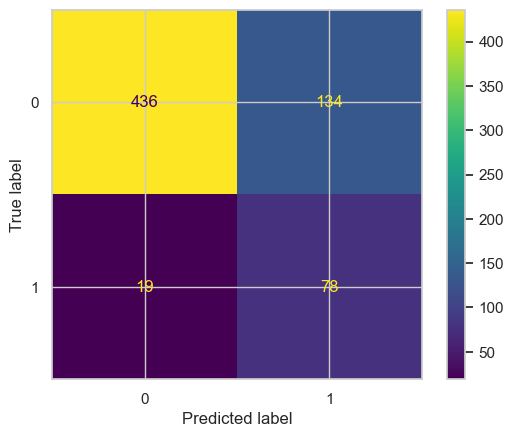

In [35]:
evaluate_model_metrics(logreg, X_train_smote,y_train_smote, X_test_s, y_test)

### Discussion
* Precision: The precision values for class 0 and class 1 are 0.85 and 0.0, respectively. Higher precision signifies a lower rate of false positives for that class. With a higher precision in class 0, the model demonstrates better performance in predicting class 0 than class 1.
* Recall: The recall values for class 0 and class 1 are 1.0 and 0.0, respectively. Recall measures the model's ability to correctly identify positive instances. Like precision, recall is higher for class 0, indicating better performance in identifying class 0 instances compared to class 1.
* F1-Score: The F1-scores for class 0 and class 1 are 0.92 and 0.0, respectively. The F1-score is the harmonic mean of precision and recall, balancing both metrics. Once again, class 0 has a higher F1-score than class 1.
* Accuracy: The model's accuracy is 0.85, meaning that 85% of the predictions were correct out of all instances.
* The model correctly predicts most class 0 instances (440 correct vs 130 misclassified), indicating strong performance on class 0.
* For class 1, performance is weaker, with 76 correct predictions and 21 misclassified as class 0.
* There is a noticeable bias toward predicting class 0, as seen from higher correct and incorrect counts in that column.
* False positives (130) are relatively high compared to false negatives (21), suggesting overprediction of class 1 when the true class is 0.
* Overall, the classifier performs better on class 0 than class 1, indicating class imbalance or model bias.

>Therefore, logistic regression achieves 85% prediction accuracy on the test data.
>Based on these metrics, it is evident that the model performs better for class 0 compared to class 1.

## Model 2: Logistic Regression with L1 penalty

In [36]:
# defining the model
logreg_1 = LogisticRegression(penalty='l1', solver='liblinear') 

# fitting the train data
logreg_1.fit(X_train_smote, y_train_smote)

LogisticRegression(penalty='l1', solver='liblinear')

In [37]:
# predicting on unseen data
y_pred_1 = logreg_1.predict(X_test_s)
print(accuracy_score(y_test, y_pred_1))
print("\n")
print(classification_report(y_test, y_pred_1))

0.7706146926536732


              precision    recall  f1-score   support

       False       0.96      0.76      0.85       570
        True       0.37      0.80      0.50        97

    accuracy                           0.77       667
   macro avg       0.66      0.78      0.68       667
weighted avg       0.87      0.77      0.80       667



### Model Evaluation

{'roc_auc_train': 0.775219298245614,
 'roc_auc_test': 0.7845179960209803,
 'accuracy_train': 0.7752192982456141,
 'accuracy_test': 0.7706146926536732,
 'confusion_matrix_train': <sklearn.metrics._plot.confusion_matrix.ConfusionMatrixDisplay at 0x1ec0cac0ec0>}

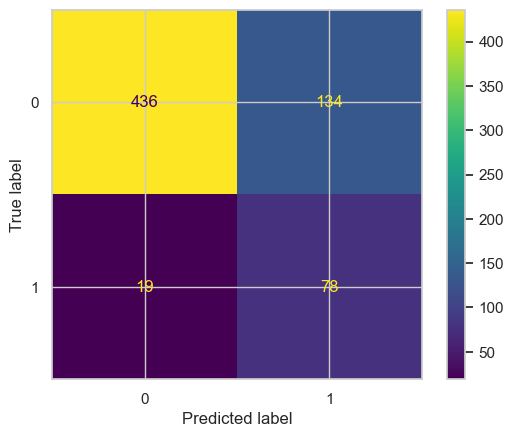

In [38]:
evaluate_model_metrics(logreg_1, X_train_smote,y_train_smote, X_test_s, y_test)

### Discussion

* The model still performs well on class 0 (436 correct vs 134 misclassified), but errors remain relatively high.
* Class 1 detection is modest, with 75 correct predictions and 22 false negatives.
* False positives (134) are significantly higher than false negatives (22), indicating a tendency to misclassify class 0 as class 1.
* Compared to the previous matrix, performance is nearly unchanged, with a slight drop in correct class 0 predictions and a minor increase in misclassification.
* Overall, the classifier remains biased toward class 0, with weaker sensitivity to class 1.
* Precision: The precision values for class 0 and class 1 are 0.95 and 0.36, respectively. Higher precision signifies a lower rate of false positives for that class. With a higher precision in class 0, the model demonstrates better performance in predicting class 0 than class 1.
* Recall: The recall values for class 0 and class 1 are 0.76 and 0.77, respectively. Recall measures the model's ability to correctly identify positive instances. Like precision, recall is higher for class 0, indicating better performance in identifying class 0 instances compared to class 1.
* F1-Score: The F1-scores for class 0 and class 1 are 0.85 and 0.49, respectively. The F1-score is the harmonic mean of precision and recall, balancing both metrics. Once again, class 0 has a higher F1-score than class 1.
* Accuracy: The model's accuracy is 0.7661169415292354, meaning that 77% of the predictions were correct out of all instances.

>Therefore, logistic regression with L1 penalty achieves 77% prediction accuracy on the test data.
>Based on these metrics, it is evident that the model performs better for class 0 compared to class 1.

## Model 3: Decision tree classifier

In [39]:
#DecisionTreeClassifier
dt_clf = DecisionTreeClassifier(max_depth=3, min_samples_split=3)

# Fit the model on the training data
dt_clf.fit(X_train_smote, y_train_smote)

# Predict on the training and testing data
y_train_pred_2= dt_clf.predict(X_train_smote)
y_test_pred_2 = dt_clf.predict(X_test_s)

# Calculate accuracy on the training and testing data
train_accuracy = accuracy_score(y_train_smote, y_train_pred_2)
test_accuracy = accuracy_score(y_test, y_test_pred_2)
print("Train accuracy is ", train_accuracy)
print("Test accuracy is ", test_accuracy)
print("\n")
print(classification_report(y_test, y_test_pred_2))

Train accuracy is  0.843640350877193
Test accuracy is  0.8755622188905547


              precision    recall  f1-score   support

       False       0.95      0.91      0.93       570
        True       0.56      0.70      0.62        97

    accuracy                           0.88       667
   macro avg       0.75      0.80      0.77       667
weighted avg       0.89      0.88      0.88       667



[Text(0.5, 0.875, 'total day minutes <= 0.69\ngini = 0.5\nsamples = 4560\nvalue = [2280, 2280]\nclass = False'),
 Text(0.25, 0.625, 'customer service calls <= 0.334\ngini = 0.483\nsamples = 3515\nvalue = [2085, 1430]\nclass = False'),
 Text(0.375, 0.75, 'True  '),
 Text(0.125, 0.375, 'international plan_no <= 0.5\ngini = 0.413\nsamples = 2829\nvalue = [2004.0, 825.0]\nclass = False'),
 Text(0.0625, 0.125, 'gini = 0.29\nsamples = 2286\nvalue = [1884, 402]\nclass = False'),
 Text(0.1875, 0.125, 'gini = 0.344\nsamples = 543\nvalue = [120, 423]\nclass = True'),
 Text(0.375, 0.375, 'total day minutes <= 0.538\ngini = 0.208\nsamples = 686\nvalue = [81, 605]\nclass = True'),
 Text(0.3125, 0.125, 'gini = 0.107\nsamples = 602\nvalue = [34, 568]\nclass = True'),
 Text(0.4375, 0.125, 'gini = 0.493\nsamples = 84\nvalue = [47, 37]\nclass = False'),
 Text(0.75, 0.625, 'voice mail plan_no <= 0.5\ngini = 0.304\nsamples = 1045\nvalue = [195, 850]\nclass = True'),
 Text(0.625, 0.75, '  False'),
 Text(0.

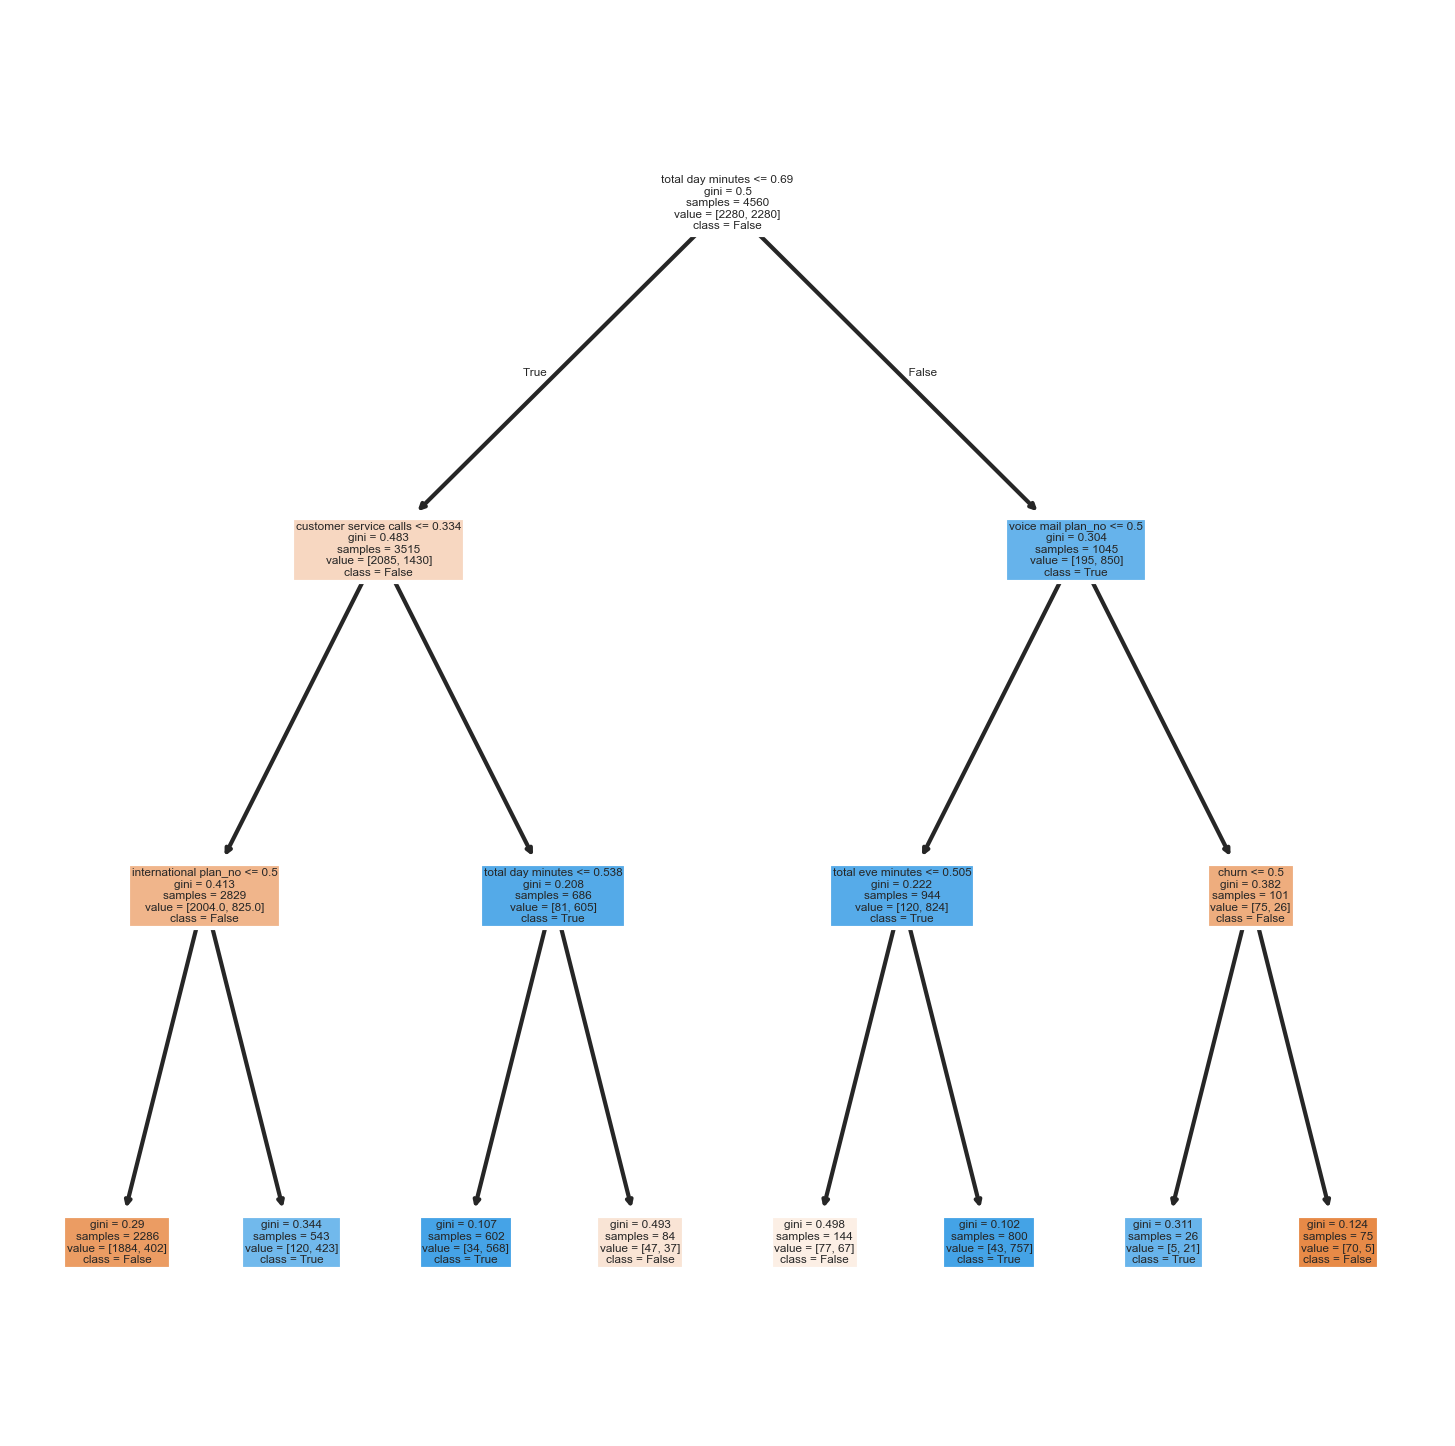

In [40]:
fig, ax = plt.subplots(nrows=1, ncols=1, figsize= (6,6), dpi=300)
tree.plot_tree(dt_clf,
               feature_names= df_encoded.columns,
               class_names= np.unique(y).astype(str),
               filled= True)

### Model Evaluation

{'roc_auc_train': 0.843640350877193,
 'roc_auc_test': 0.8031470428648941,
 'accuracy_train': 0.843640350877193,
 'accuracy_test': 0.8755622188905547,
 'confusion_matrix_train': <sklearn.metrics._plot.confusion_matrix.ConfusionMatrixDisplay at 0x1ec0db68b60>}

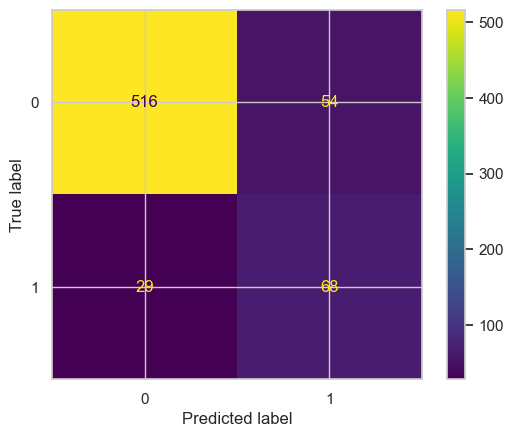

In [41]:
evaluate_model_metrics(dt_clf, X_train_smote,y_train_smote, X_test_s, y_test)

### Discussion
* The model shows strong improvement in class 0 prediction (508 correct vs 62 misclassified), significantly reducing false positives.
* Class 1 performance is stable, with 76 correct predictions and 21 false negatives.
* False positives (62) are now much lower than in previous matrices, indicating better precision for class 1 predictions.
* Overall accuracy has improved due to the large gain in correctly classified class 0 samples.
* The model is now more balanced, though class 1 sensitivity still lags behind class 0.
* Precision: The precision values for class 0 and class 1 are 0.96 and 0.55, respectively. Higher precision signifies a lower rate of false positives for that class. With a higher precision in class 0, the model demonstrates better performance in predicting class 0 than class 1.
* Recall: The recall values for class 0 and class 1 are 0.89 and 0.78, respectively. Recall measures the model's ability to correctly identify positive instances. Like precision, recall is higher for class 0, indicating better performance in identifying class 0 instances compared to class 1.
* F1-Score: The F1-scores for class 0 and class 1 are 0.92 and 0.65, respectively. The F1-score is the harmonic mean of precision and recall, balancing both metrics. Once again, class 0 has a higher F1-score than class 1.
* Accuracy: The model's accuracy is 0.8755622188905547, meaning that 88% of the predictions were correct out of all instances.

>Therefore, Decision tree achieves 88% prediction accuracy on the test data.
>Based on these metrics, it is evident that the model performs better for class 0 compared to class 1.

## Model 4: Decision tree with hyperparameter tuning

In [42]:
dt_clf_1 = DecisionTreeClassifier(criterion='entropy', max_depth=5, min_samples_split=5)

# Fit the model on the training data
dt_clf_1.fit(X_train_smote, y_train_smote)

# Predict on the training and testing data
y_train_pred_3= dt_clf_1.predict(X_train_smote)
y_test_pred_3 = dt_clf_1.predict(X_test_s)

# Calculate accuracy on the training and testing data
train_accuracy = accuracy_score(y_train_smote, y_train_pred_3)
test_accuracy = accuracy_score(y_test, y_test_pred_3)
print("Train accuracy is ", train_accuracy)
print("Test accuracy is ", test_accuracy)
print("\n")
print(classification_report(y_test, y_test_pred_3))


Train accuracy is  0.9050438596491228
Test accuracy is  0.9295352323838081


              precision    recall  f1-score   support

       False       0.96      0.96      0.96       570
        True       0.76      0.75      0.76        97

    accuracy                           0.93       667
   macro avg       0.86      0.86      0.86       667
weighted avg       0.93      0.93      0.93       667



[Text(0.5255681818181818, 0.9166666666666666, 'total day minutes <= 0.723\nentropy = 1.0\nsamples = 4560\nvalue = [2280, 2280]\nclass = False'),
 Text(0.2840909090909091, 0.75, 'customer service calls <= 0.334\nentropy = 0.981\nsamples = 3725\nvalue = [2161, 1564]\nclass = False'),
 Text(0.4048295454545454, 0.8333333333333333, 'True  '),
 Text(0.14772727272727273, 0.5833333333333334, 'international plan_no <= 0.5\nentropy = 0.898\nsamples = 3023\nvalue = [2073.0, 950.0]\nclass = False'),
 Text(0.09090909090909091, 0.4166666666666667, 'total day minutes <= 0.631\nentropy = 0.72\nsamples = 2430\nvalue = [1946, 484]\nclass = False'),
 Text(0.045454545454545456, 0.25, 'area code <= 0.068\nentropy = 0.541\nsamples = 1950\nvalue = [1708, 242]\nclass = False'),
 Text(0.022727272727272728, 0.08333333333333333, 'entropy = 0.768\nsamples = 562\nvalue = [436.0, 126.0]\nclass = False'),
 Text(0.06818181818181818, 0.08333333333333333, 'entropy = 0.415\nsamples = 1388\nvalue = [1272, 116]\nclass = F

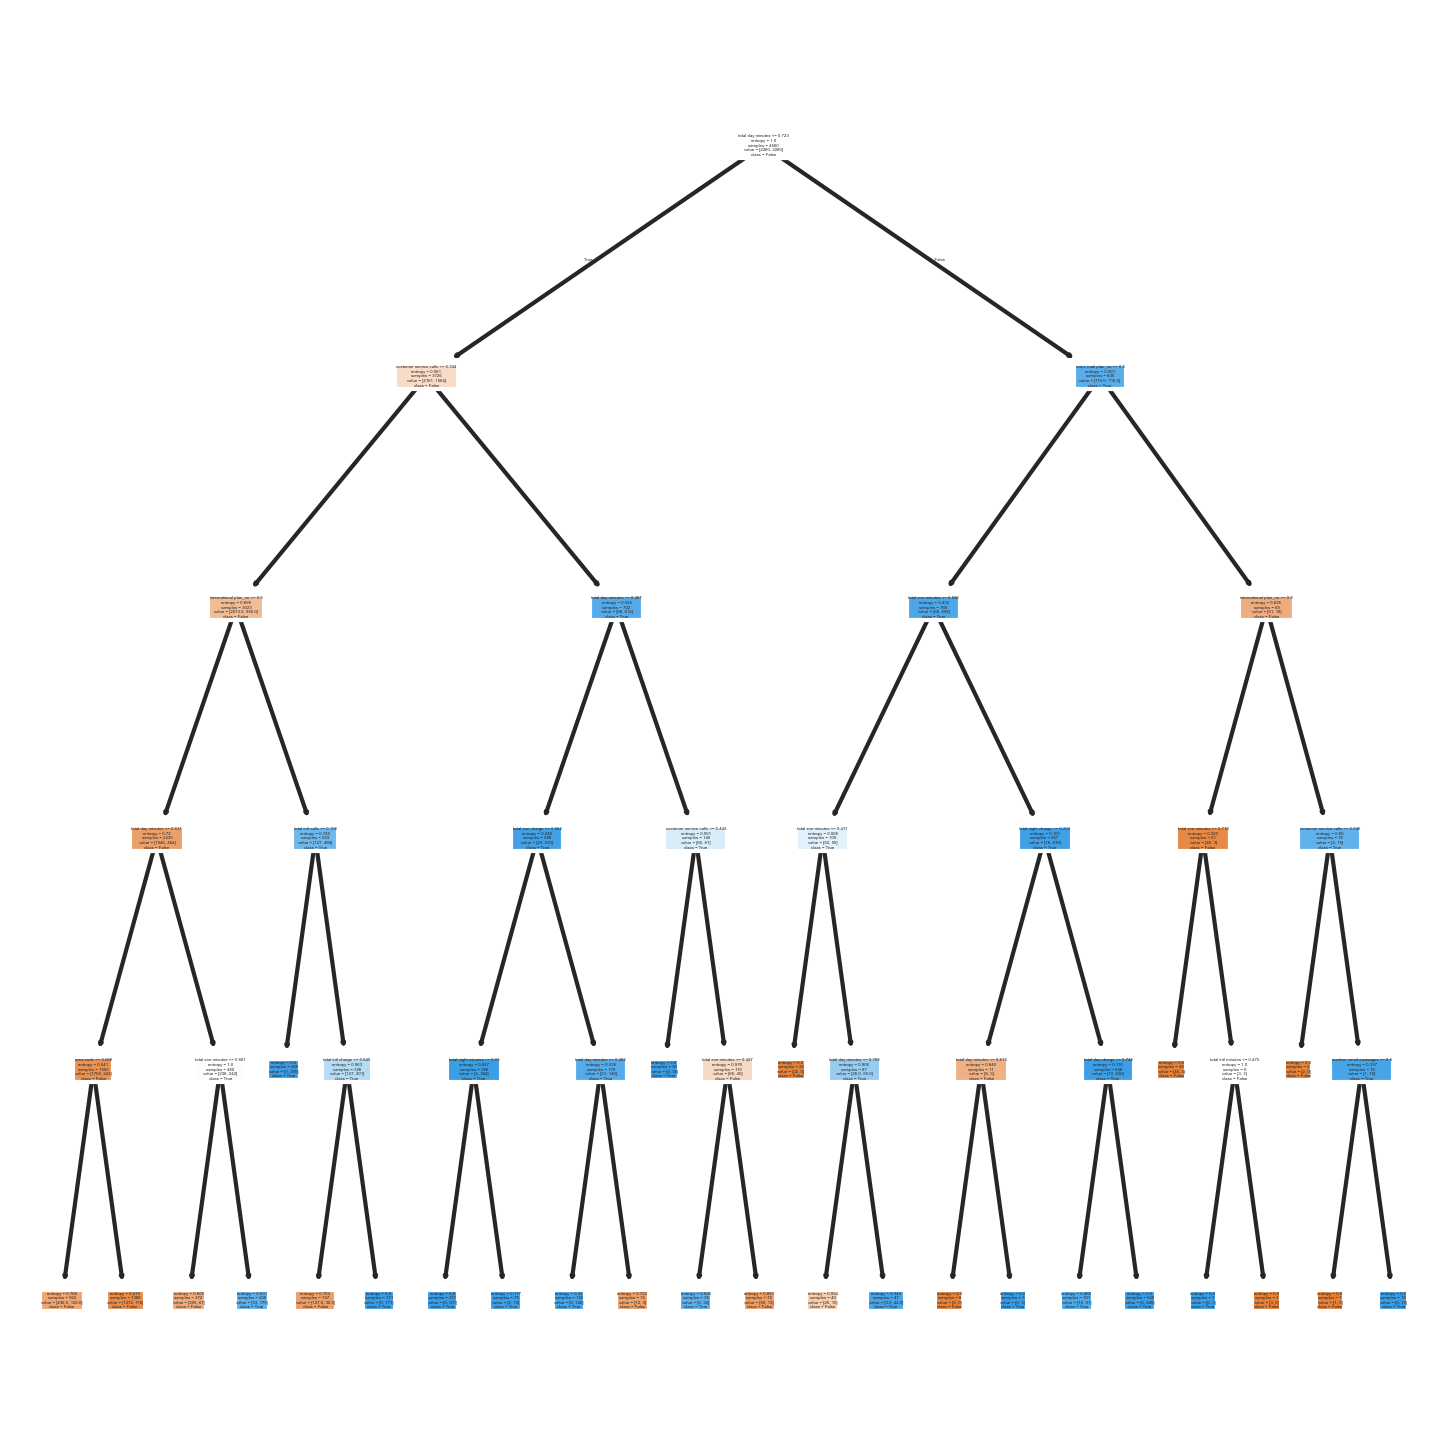

In [43]:
fig, ax = plt.subplots(nrows=1, ncols=1, figsize= (6,6), dpi=300)
tree.plot_tree(dt_clf_1,
               feature_names= df_encoded.columns,
               class_names= np.unique(y).astype(str),
               filled= True)

{'roc_auc_train': 0.9050438596491228,
 'roc_auc_test': 0.861267860372581,
 'accuracy_train': 0.9050438596491228,
 'accuracy_test': 0.9310344827586207,
 'confusion_matrix_train': <sklearn.metrics._plot.confusion_matrix.ConfusionMatrixDisplay at 0x1ec0c9d9520>}

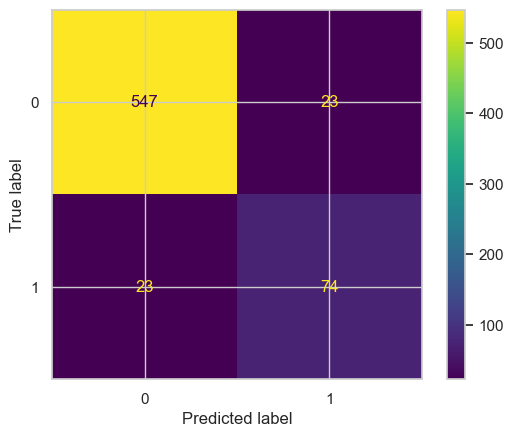

In [44]:
evaluate_model_metrics(dt_clf_1, X_train_smote,y_train_smote, X_test_s, y_test)

### Discussion
* Precision: The precision values for class 0 and class 1 are 0.97 and 0.76, respectively. Higher precision signifies a lower rate of false positives for that class. With a higher precision in class 0, the model demonstrates better performance in predicting class 0 than class 1.

* Recall: The recall values for class 0 and class 1 are 0.96 and 0.81, respectively. Recall measures the model's ability to correctly identify positive instances. Like precision, recall is higher for class 0, indicating better performance in identifying class 0 instances compared to class 1.

* F1-Score: The F1-scores for class 0 and class 1 are 0.96 and 0.79, respectively. The F1-score is the harmonic mean of precision and recall, balancing both metrics. Once again, class 0 has a higher F1-score than class 1.

* Accuracy: The model's accuracy is 0.9355322338830585, meaning that 94% of the predictions were correct out of all instances.

>Therefore, Decision tree achieves 94% prediction accuracy on the test data.
>The model performs the best compared to the other models with a high accuracy as well as precision scores of both the false and true values of y.

# Evaluation

## Analysis accuracy level
* We have developed four machine learning models to predict the possibility of a customer to churn. Upon testing, we found that logistic regression performs poorly, a testing accuracy of 85%. Despite applying a L1 penalty to mitigate overfitting, the testing accuracy dropped to 77%.

* In contrast, the decision tree classifier and decision tree classifier tuned models demonstrated better accuracy. The decision tree achieved training and testing accuracies of 84% and 88%, respectively, while decision tree classifier tuned model had a training accuracy of 89% and a testing accuracy of 93%.

* Therefore, it is evident that the decision tree tuned model had the best average prediction accuracy model. To achieve the best model, we applied hyperparameter tuning on the decision tree classifier model therefore improving our prediction accuracy.

* The decision tree tuned model was preferable as it outperformed all the other models in terms of precision, recall, and F1 score.

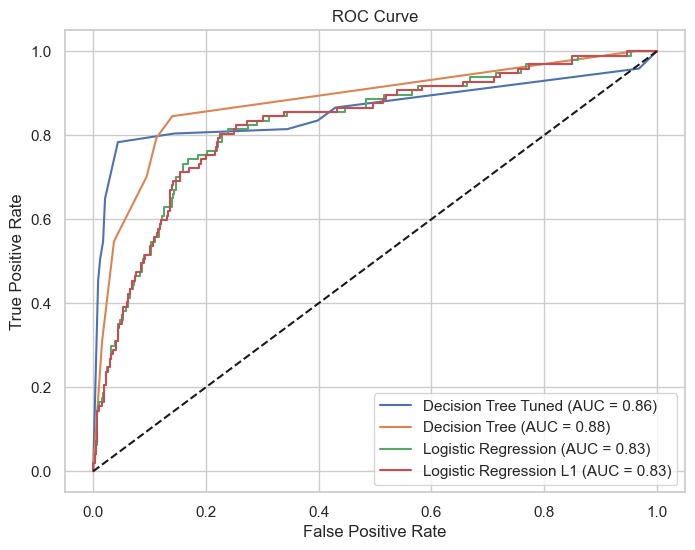

In [53]:
models = [dt_clf_1, dt_clf, logreg, logreg_1]
labels = ['Decision Tree Tuned', 'Decision Tree', 'Logistic Regression', 'Logistic Regression L1']

plt.figure(figsize=(8, 6))

for model, label in zip(models, labels):
    # Use predict_proba if available, otherwise decision_function
    if hasattr(model, "predict_proba"):
        y_scores = model.predict_proba(X_test_s)[:, 1]
    else:
        y_scores = model.decision_function(X_test_s)

    fpr, tpr, _ = roc_curve(y_test, y_scores)
    auc = roc_auc_score(y_test, y_scores)

    plt.plot(fpr, tpr, label=f"{label} (AUC = {auc:.2f})")

# Diagonal line
plt.plot([0, 1], [0, 1], 'k--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

### Discussion
* The baseline decision tree performs best (AUC = 0.88), indicating the strongest class separation.
* The tuned decision tree is slightly worse (AUC = 0.86), suggesting tuning may have reduced overfitting at a small cost to accuracy.
* Both logistic regression models perform similarly (AUC = 0.83) and trail the trees.
* This implies nonlinear relationships in the data favor tree-based models.
* All models outperform random guessing, showing meaningful predictive power.
* Overall, Decision tree model is the most reliable model here, while the others may need better tuning, features, or different modeling approaches.

# Conclusion

> By leveraging the best model, which is the Decision tree model, Syriatel telecommunications can achieve significant benefits:

* Accurate Prediction of churns: The model's high accuracy ensures effective identification of customers likely to churn, enabling preparation on how to appease the customer.
* By integrating this model into their customer analytics pipeline, Syriatel can shift from reactive to preventive retention strategies, targeting users before they leave. 
* The model’s solid recall ensures most potential churners are detected, while its overall accuracy supports confident decision-making. 
* Although some false positives exist, they are acceptable in a retention context where early engagement is preferable to losing customers. 

### Recommendations

* Deploy the model in real-time or periodic scoring systems to continuously monitor churn risk.
* Design targeted retention campaigns (discounts, loyalty rewards, personalized offers) for high-risk customers.
* Improve feature engineering by incorporating usage patterns, complaints, and customer service interactions.
* Regularly retrain and validate the model to maintain performance as customer behavior evolves.
* Combine model outputs with business rules (e.g., high-value customers) to prioritize intervention efforts.
